### MODEL 3(a)

In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [231]:
df = pd.read_csv('categorised_e11.csv')

In [222]:
from sklearn.model_selection import cross_val_score

k_values = [30,35, 40,41,42,43,44,45,46, 47, 48, 49, 50]

for k in k_values:
    selector = SelectKBest(f_regression, k=k)
    x_train_selected = selector.fit_transform(x_train, y_train)
    
    scores = cross_val_score(LinearRegression(), x_train_selected, y_train, cv=5) 
    print(f'k={k}, Mean Cross-Validation Score: {np.mean(scores)}')


ValueError: k should be <= n_features = 8; got 30. Use k='all' to return all features.

In [232]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df.drop(columns=['c241'])
y = df['c241']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=58)

k = 45
selector = SelectKBest(f_regression, k=k)
x_train_selected = selector.fit_transform(x_train, y_train)

selected_features = X.columns[selector.get_support()]

print('Selected Features:', selected_features)

Selected Features: Index(['c19', 'c28', 'c29', 'c58', 'c60', 'c64', 'c67', 'c70', 'c74', 'c75',
       'c76', 'c77', 'c81', 'c83', 'c84', 'c88', 'c90', 'c94', 'c95', 'c101',
       'c103', 'c111', 'c115', 'c120', 'c133', 'c134', 'c139', 'c141', 'c142',
       'c143', 'c144', 'c125', 'c129', 'c151', 'c167', 'c173', 'c180', 'c181',
       'c186', 'c201', 'c203', 'c205', 'c224', 'c225', 'c227'],
      dtype='object')


In [233]:
feature_list = list(selected_features)

In [234]:
columns_to_remove = [] 
for i in range(len(feature_list)):
    for j in range(i+1, len(feature_list)):
        col1 = feature_list[i]
        col2 = feature_list[j] 
        corr_coefficient = df[col1].corr(df[col2])
        if abs(corr_coefficient) >= 0.71:
            columns_to_remove.append(col2)
feature_list = [col for col in feature_list if col not in columns_to_remove]
print(feature_list)

['c19', 'c28', 'c29', 'c58', 'c60', 'c67', 'c111']


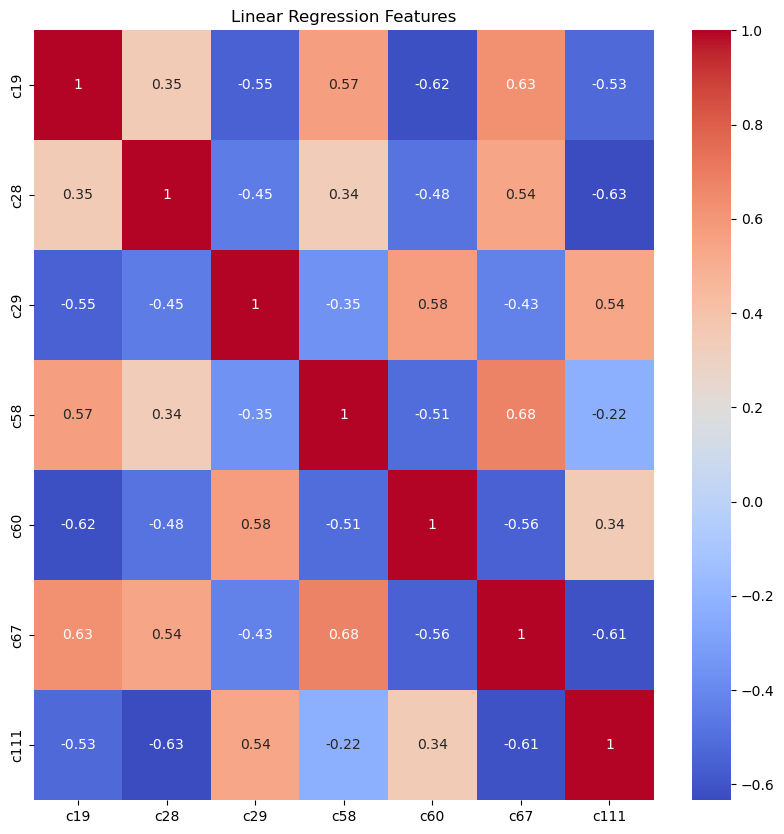

In [235]:
import seaborn as sns
correlation_matrix = df[feature_list].corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Linear Regression Features')
plt.show()

In [239]:
from sklearn.metrics import mean_squared_error, r2_score

X = df[feature_list]
X =  sm.add_constant(X)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
mlr_model = sm.OLS(y_train, x_train).fit()
print(mlr_model.summary())

y_pred = mlr_model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('\n')
print(f'Mean Squared Error of testing data: {mse}')
print(f'R-squared for testing data: {r2}')

                            OLS Regression Results                            
Dep. Variable:                   c241   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     875.2
Date:                Sun, 12 Nov 2023   Prob (F-statistic):               0.00
Time:                        09:47:44   Log-Likelihood:                 1536.1
No. Observations:                 717   AIC:                            -3056.
Df Residuals:                     709   BIC:                            -3020.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0099      0.010    197.430      0.0

In [240]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming you already have x_train as your design matrix with all the predictor variables

# Calculate VIF for each column in x_train
vif_data = pd.DataFrame()
vif_data["Variable"] = x_train.columns
vif_data["VIF"] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]

# Display the VIF data
print(vif_data)

  Variable        VIF
0    const  91.090992
1      c19   2.692507
2      c28   2.040389
3      c29   1.917804
4      c58   2.524878
5      c60   2.386144
6      c67   3.477036
7     c111   3.023410


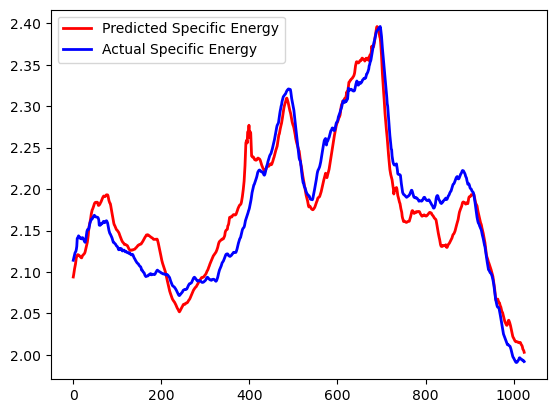

In [241]:
y_total_pred = mlr_model.predict(X)
plt.plot(y_total_pred, color='red', linestyle='-', linewidth=2)
plt.plot(y, color='blue', linestyle='-', linewidth=2)
plt.legend(labels=['Predicted Specific Energy', 'Actual Specific Energy'])